In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score,mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [79]:
fetch_california_housing()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [80]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [81]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [82]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587
1,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162
2,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603
3,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698
4,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551


In [83]:
linear_reg = LinearRegression()

linear_reg.fit(X_train, y_train)

LinearRegression()

In [84]:
linear_pred = linear_reg.predict(X_test)
linear_pred

linear_r2 = r2_score(y_test, linear_pred)
print("Linear R2 score: ", linear_r2)

linear_mse = mean_squared_error(y_test, linear_pred)
print("Linear MSE: ", linear_mse)

linear_rmse = np.sqrt(linear_mse)
print("Linear RMSE: ", linear_rmse)

linear_mae = mean_absolute_error(y_test, linear_pred)
print("Linear MAE: ", linear_mae)

#Feature importance (coefficients)
print(linear_reg.coef_)      # importance of a particular feature in predicting the MedHouseVa
print(df.columns)            # To compare the order of these column names with the order of the coefficients

Linear R2 score:  0.575787706032451
Linear MSE:  0.5558915986952442
Linear RMSE:  0.7455813830127763
Linear MAE:  0.5332001304956565
[ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


In [109]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
print("CV R2:", scores.mean())

CV R2: 0.5530311140279566


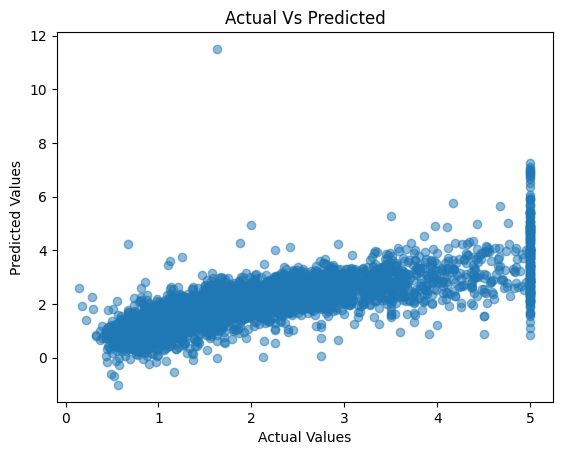

In [86]:
plt.scatter(y_test, linear_pred, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title("Actual Vs Predicted")
plt.show()         # If points are not near diagonal → model is weak

In [87]:
# RIDGE REGRESSION => L2 regularization
params = {
    'alpha' : [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
}

grid = GridSearchCV(Ridge(), params, cv=5, scoring='r2')
grid.fit(X_train, y_train)
print("Best alpha:", grid.best_params_)
print("CV Score:", grid.best_score_)
# best_model = grid.best_estimator_
# pred = best_model.predict(X_test)
ridge_reg = Ridge(alpha=grid.best_params_['alpha'])   # best_params_ => dictionary
ridge_reg.fit(X_train, y_train)
ridge_pred = ridge_reg.predict(X_test)
ridge_pred

Best alpha: {'alpha': 0.0001}
CV Score: 0.611483995255776


array([0.71912288, 1.76401655, 2.7096588 , ..., 4.46877014, 1.18751123,
       2.00940249])

In [88]:
ridge_r2 = r2_score(y_test, ridge_pred)
print("Ridge R2 score: ", ridge_r2)

ridge_mse = mean_squared_error(y_test, ridge_pred)
print("Ridge MSE: ", ridge_mse)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
print("Ridge MAE: ", ridge_mae)

ridge_rmse = np.sqrt(ridge_mse)
print("Ridge RMSE: ", ridge_rmse)

print("Coefficients:", ridge_reg.coef_)
print("Columns: ",df.columns)

Ridge R2 score:  0.5757877088453394
Ridge MSE:  0.5558915950092099
Ridge MAE:  0.533200129779773
Ridge RMSE:  0.7455813805408568
Coefficients: [ 0.85438303  0.12254625 -0.29441011  0.33925947 -0.00230772 -0.0408291
 -0.8969288  -0.8698417 ]
Columns:  Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


In [111]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=ridge_reg.alpha))
])

ridge_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')

print("CV R2:", ridge_scores.mean())

# print("CV Score:", grid.best_score_)

CV R2: 0.5530311143500617


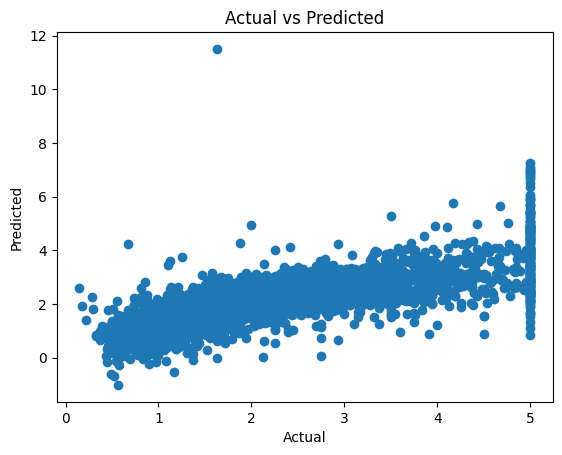

In [90]:
plt.scatter(y_test, ridge_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [91]:
# LASSO REGRESSION => L1 regularization
params = {
    'alpha' : [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
}

grid = GridSearchCV(Lasso(), params, cv=5, scoring='r2')
grid.fit(X_train, y_train)
print("Best alpha:", grid.best_params_)
print("CV Score:", grid.best_score_)
# best_model = grid.best_estimator_
# pred = best_model.predict(X_test)
lasso_reg = Lasso(alpha=grid.best_params_['alpha'])   # best_params_ => dictionary
lasso_reg.fit(X_train, y_train)
lasso_pred = lasso_reg.predict(X_test)
print(lasso_pred)

Best alpha: {'alpha': 0.001}
CV Score: 0.6114974494713218
[0.72592298 1.76090866 2.69570697 ... 4.46264973 1.19821254 2.00356126]


In [107]:
lasso_r2 = r2_score(y_test, lasso_pred)
print("Lasso R2 score: ", lasso_r2)

lasso_mse = mean_squared_error(y_test, lasso_pred)
print("Lasso MSE: ", lasso_mse)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
print("Lasso MAE: ", lasso_mae)

lasso_rmse = np.sqrt(lasso_mse)
print("Lasso RMSE: ", lasso_rmse)

# print("Coefficients:", lasso_reg.coef_)
# print("Columns: ",df.columns)
# best_model = grid.best_estimator_ # This line caused the error due to global variable reassignment
for name, coef in zip(X.columns, lasso_reg.coef_):
    print(name, coef)

Lasso R2 score:  0.5768562568705682
Lasso MSE:  0.5544913600832686
Lasso MAE:  0.5331447750392391
Lasso RMSE:  0.7446417662764214
MedInc 0.8491403811015727
HouseAge 0.12334630607817225
AveRooms -0.2812733329271337
AveBedrms 0.32604962906311663
Population -0.0010618537261602957
AveOccup -0.039889537255593605
Latitude -0.8858221695143402
Longitude -0.8580932384664084


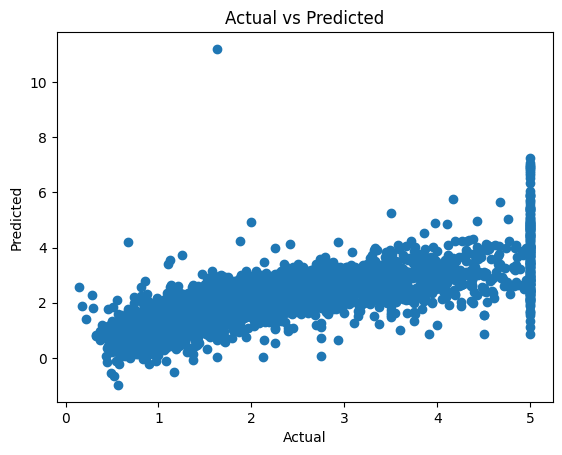

In [93]:
plt.scatter(y_test, lasso_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()
# regularization isn’t significantly affecting the model => same scatter plots so far

In [94]:
# Decision Tree Regressor
# step-like predictions & not smooth like linear =>
# if x < 2 → predict 1.5
# if 2 ≤ x < 5 → predict 3.2
# if x ≥ 5 → predict 4.8

tree = DecisionTreeRegressor(max_depth=5)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)
print("Tree Model Predictions: ",tree_pred)
for name, importance in zip(X.columns, tree.feature_importances_):
    print(name, importance)

Tree Model Predictions:  [1.16857267 1.27158128 3.19958174 ... 4.86065073 1.27158128 1.64279735]
MedInc 0.7712117162048124
HouseAge 0.0416208799360859
AveRooms 0.03126072126800345
AveBedrms 0.0008685076668094419
Population 0.002484998287179886
AveOccup 0.1284067461489496
Latitude 0.022049480286783798
Longitude 0.002096950201375441


In [95]:
print("Tree R2:", r2_score(y_test, tree_pred))
print("Tree MSE:", mean_squared_error(y_test, tree_pred))
print("Tree MAE:", mean_absolute_error(y_test, tree_pred))
print("Tree RMSE:", np.sqrt(mean_squared_error(y_test, tree_pred)))

Tree R2: 0.5997321244428706
Tree MSE: 0.5245146178314735
Tree MAE: 0.5222592972077786
Tree RMSE: 0.7242338143386247


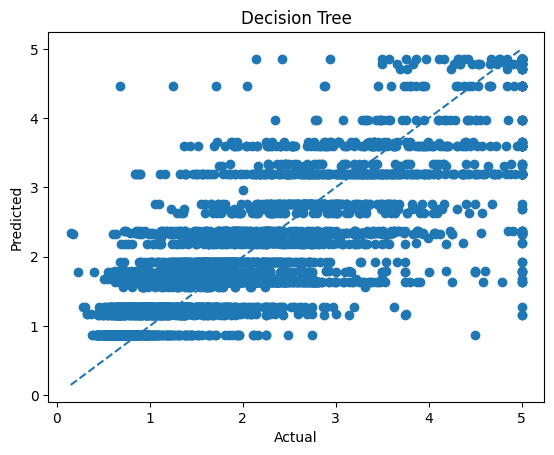

In [96]:
plt.scatter(y_test, tree_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')        # forms dashed diagonal to (min,min) to (max,max)
plt.title("Decision Tree")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()
#Points ABOVE → overprediction
#Points BELOW → underprediction

In [97]:
# Random Forest Regressor => many decision trees + averaging
# Random Forest improves over Decision Tree by reducing overfitting through ensemble learning, resulting in more stable and accurate predictions.
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random forest predictions: ", rf_pred)

Random forest predictions:  [0.56803151 0.81136037 4.83575176 ... 4.78361343 0.77196344 1.66051165]


In [98]:
print("RF R2:", r2_score(y_test, rf_pred))
print("RF MSE:", mean_squared_error(y_test, rf_pred))
print("RF MAE:", mean_absolute_error(y_test, rf_pred))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
for name, imp in zip(X.columns, rf.feature_importances_):
    print(name, imp)

RF R2: 0.7738887441938533
RF MSE: 0.29629821968969944
RF MAE: 0.36628865979805514
RF RMSE: 0.5443328206986048
MedInc 0.5938052482296236
HouseAge 0.04792088228293173
AveRooms 0.03153909175689916
AveBedrms 0.01701697776923213
Population 0.017259671396907556
AveOccup 0.13975929629088407
Latitude 0.07659260359506681
Longitude 0.0761062286784549


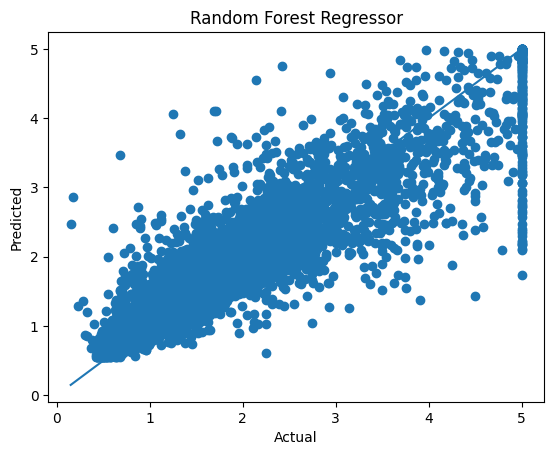

In [99]:
plt.scatter(y_test, rf_pred)
plt.plot([y_test.min(), y_test.max()],
          [y_test.min(), y_test.max()])
plt.title("Random Forest Regressor")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [108]:
# XGBOOST => Boosting ensemble
# xgb = XGBRegressor(n_estimators=100,
#                    max_depth=6,
#                    random_state=42,
#                    learning_rate=0.1)

# xgb.fit(X_train, y_train)
# xgb_pred = xgb.predict(X_test)
# print("XGBoost predictions: ", xgb_pred)

params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

grid = GridSearchCV(XGBRegressor(random_state=42, verbosity=0), params, cv=5, scoring='r2')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
xgb_pred = best_model.predict(X_test)
print("XGBoost predictions: ", xgb_pred)

XGBoost predictions:  [0.57173526 0.9221716  5.1726966  ... 4.7959137  0.78753275 1.8128107 ]


In [101]:
print("R2:", r2_score(y_test, xgb_pred))
print("MSE:", mean_squared_error(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
for name, imp in zip(X.columns, best_model.feature_importances_):
    print(name, imp)

R2: 0.835795246184819
MSE: 0.2151753836692498
MAE: 0.3026459157770641
RMSE: 0.4638700072964944
MedInc 0.5132079
HouseAge 0.06557926
AveRooms 0.039865904
AveBedrms 0.02370887
Population 0.023204744
AveOccup 0.14655395
Latitude 0.0887981
Longitude 0.09908119


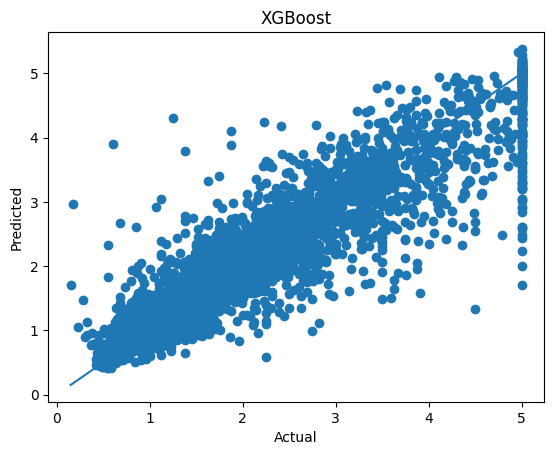

In [102]:
plt.scatter(y_test, xgb_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.title("XGBoost")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [103]:
# ADABOOST =>
ada = AdaBoostRegressor(
    estimator = DecisionTreeRegressor(max_depth=5),
    n_estimators = 100,
    random_state = 42,
    learning_rate = 0.1           # High (0.5–1) => fast learning but risky -> 0.1 --- stable
)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)
print("AdaBoost predictions: ", ada_pred)

AdaBoost predictions:  [1.15571521 1.3557953  3.58458872 ... 4.51354787 1.47644469 1.88249506]


In [104]:
print("R2:", r2_score(y_test, ada_pred))
print("MSE:", mean_squared_error(y_test, ada_pred))
print("MAE:", mean_absolute_error(y_test, ada_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ada_pred)))

R2: 0.6719038904567215
MSE: 0.4299400876714219
MAE: 0.5095050101017602
RMSE: 0.6556981681165671


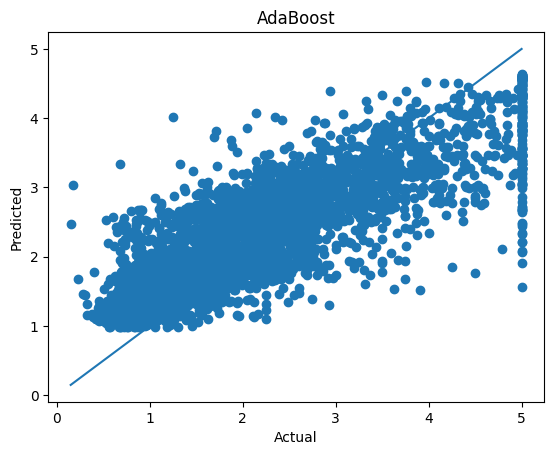

In [105]:
plt.scatter(y_test, ada_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.title("AdaBoost")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "Tree", "RF", "XGB", "Ada"],
    "R2": [linear_r2, ridge_r2, lasso_r2,
           r2_score(y_test, tree_pred),
           r2_score(y_test, rf_pred),
           r2_score(y_test, xgb_pred),
           r2_score(y_test, ada_pred)]
})

print(results)

“Linear, Ridge, and Lasso performed similarly, indicating minimal impact of regularization. Tree-based ensemble models, especially XGBoost and Random Forest, performed better by capturing non-linear relationships.”